# 📊 Phase 1A — Exploratory Data Analysis
**Project:** Worker Productivity Dashboard | **Dataset:** Garment Employees Productivity

### Goals of this notebook
1. Load and understand the shape of the data
2. Identify the target column and input features
3. Plot distributions for all numerical features
4. Visualise feature correlations with a heatmap
5. Check the target variable for skew / imbalance

> **Run cells top-to-bottom.** Plots are also saved to `data/cleaned/` for reference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Consistent plot style across all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 12

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 1A.1 — Load Dataset

In [2]:
# ⚠️  Update the filename below if yours differs after downloading from Kaggle
DATA_PATH = '../data/raw/garments_worker_productivity.csv'

df = pd.read_csv(DATA_PATH)

print(f'📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n📋 Columns:\n{df.columns.tolist()}')
print('\n👀 First 5 rows:')
df.head()

📐 Shape: 1197 rows × 15 columns

📋 Columns:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

👀 First 5 rows:


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


---
## 1A.2 — Basic Inspection

Three questions we always answer first:
- **What types are the columns?** → `.info()`
- **What are the numerical ranges?** → `.describe()`
- **Are there missing values?** → `.isnull().sum()`

In [3]:
print('=' * 55)
print('DATASET INFO')
print('=' * 55)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   floa

In [4]:
print('=' * 55)
print('STATISTICAL SUMMARY')
print('=' * 55)
df.describe().round(3)

STATISTICAL SUMMARY


,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000,1197.000,1197.000,691.000,1197.000,1197.000,1197.00,1197.000,1197.000,1197.000,1197.000
mean,6.427,0.730,15.062,1190.466,4567.460,38.211,0.73,0.369,0.150,34.610,0.735
std,3.464,0.098,10.943,1837.455,3348.824,160.183,12.71,3.269,0.428,22.198,0.174
min,1.000,0.070,2.900,7.000,0.000,0.000,0.00,0.000,0.000,2.000,0.234
25%,3.000,0.700,3.940,774.500,1440.000,0.000,0.00,0.000,0.000,9.000,0.650
50%,6.000,0.750,15.260,1039.000,3960.000,0.000,0.00,0.000,0.000,34.000,0.773
75%,9.000,0.800,24.260,1252.500,6960.000,50.000,0.00,0.000,0.000,57.000,0.850
max,12.000,0.800,54.560,23122.000,25920.000,3600.000,300.00,45.000,2.000,89.000,1.120


In [5]:
null_counts = df.isnull().sum()
null_pct    = (df.isnull().sum() / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %':     null_pct
})

# Show only columns that actually have nulls
null_df = null_df[null_df['Missing Count'] > 0]

if null_df.empty:
    print('✅  No missing values found!')
else:
    print('⚠️   Columns with missing values:')
    display(null_df)

⚠️   Columns with missing values:


,Missing Count,Missing %
wip,506,42.27


---
## 1A.3 — Identify Target Column and Input Features

| Role | Column(s) |
|------|-----------|
| 🎯 Target | `actual_productivity` — the value we will predict (float 0–1) |
| 📊 Numerical features | overtime, incentive, idle time, team size, WIP, SMV, … |
| 🏷️ Categorical features | `quarter`, `department`, `day` |
| 🗑️ Drop | `date`, `team` — not useful as model inputs |

In [6]:
TARGET = 'actual_productivity'

NUMERICAL_FEATURES = [
    'targeted_productivity', 'smv', 'wip',
    'over_time', 'incentive', 'idle_time',
    'idle_men', 'no_of_workers', 'no_of_style_change'
]

CATEGORICAL_FEATURES = ['quarter', 'department', 'day']

DROP_COLUMNS = ['date', 'team']

print(f'🎯 Target            : {TARGET}')
print(f'\n📊 Numerical Features ({len(NUMERICAL_FEATURES)}):')
for f in NUMERICAL_FEATURES:
    print(f'   {f}')
print(f'\n🏷️  Categorical Features ({len(CATEGORICAL_FEATURES)}):')
for f in CATEGORICAL_FEATURES:
    print(f'   {f}')
print(f'\n🗑️  Drop Columns: {DROP_COLUMNS}')

🎯 Target            : actual_productivity

📊 Numerical Features (9):
   targeted_productivity
   smv
   wip
   over_time
   incentive
   idle_time
   idle_men
   no_of_workers
   no_of_style_change

🏷️  Categorical Features (3):
   quarter
   department
   day

🗑️  Drop Columns: ['date', 'team']


---
## 1A.4 — Distributions of Numerical Features

**What to look for:**
- Heavy right skew (long tail to the right) → may need log transform
- Features where mean ≠ median → outlier presence
- `wip` often has many zeros — watch for that

NameError: name 'os' is not defined

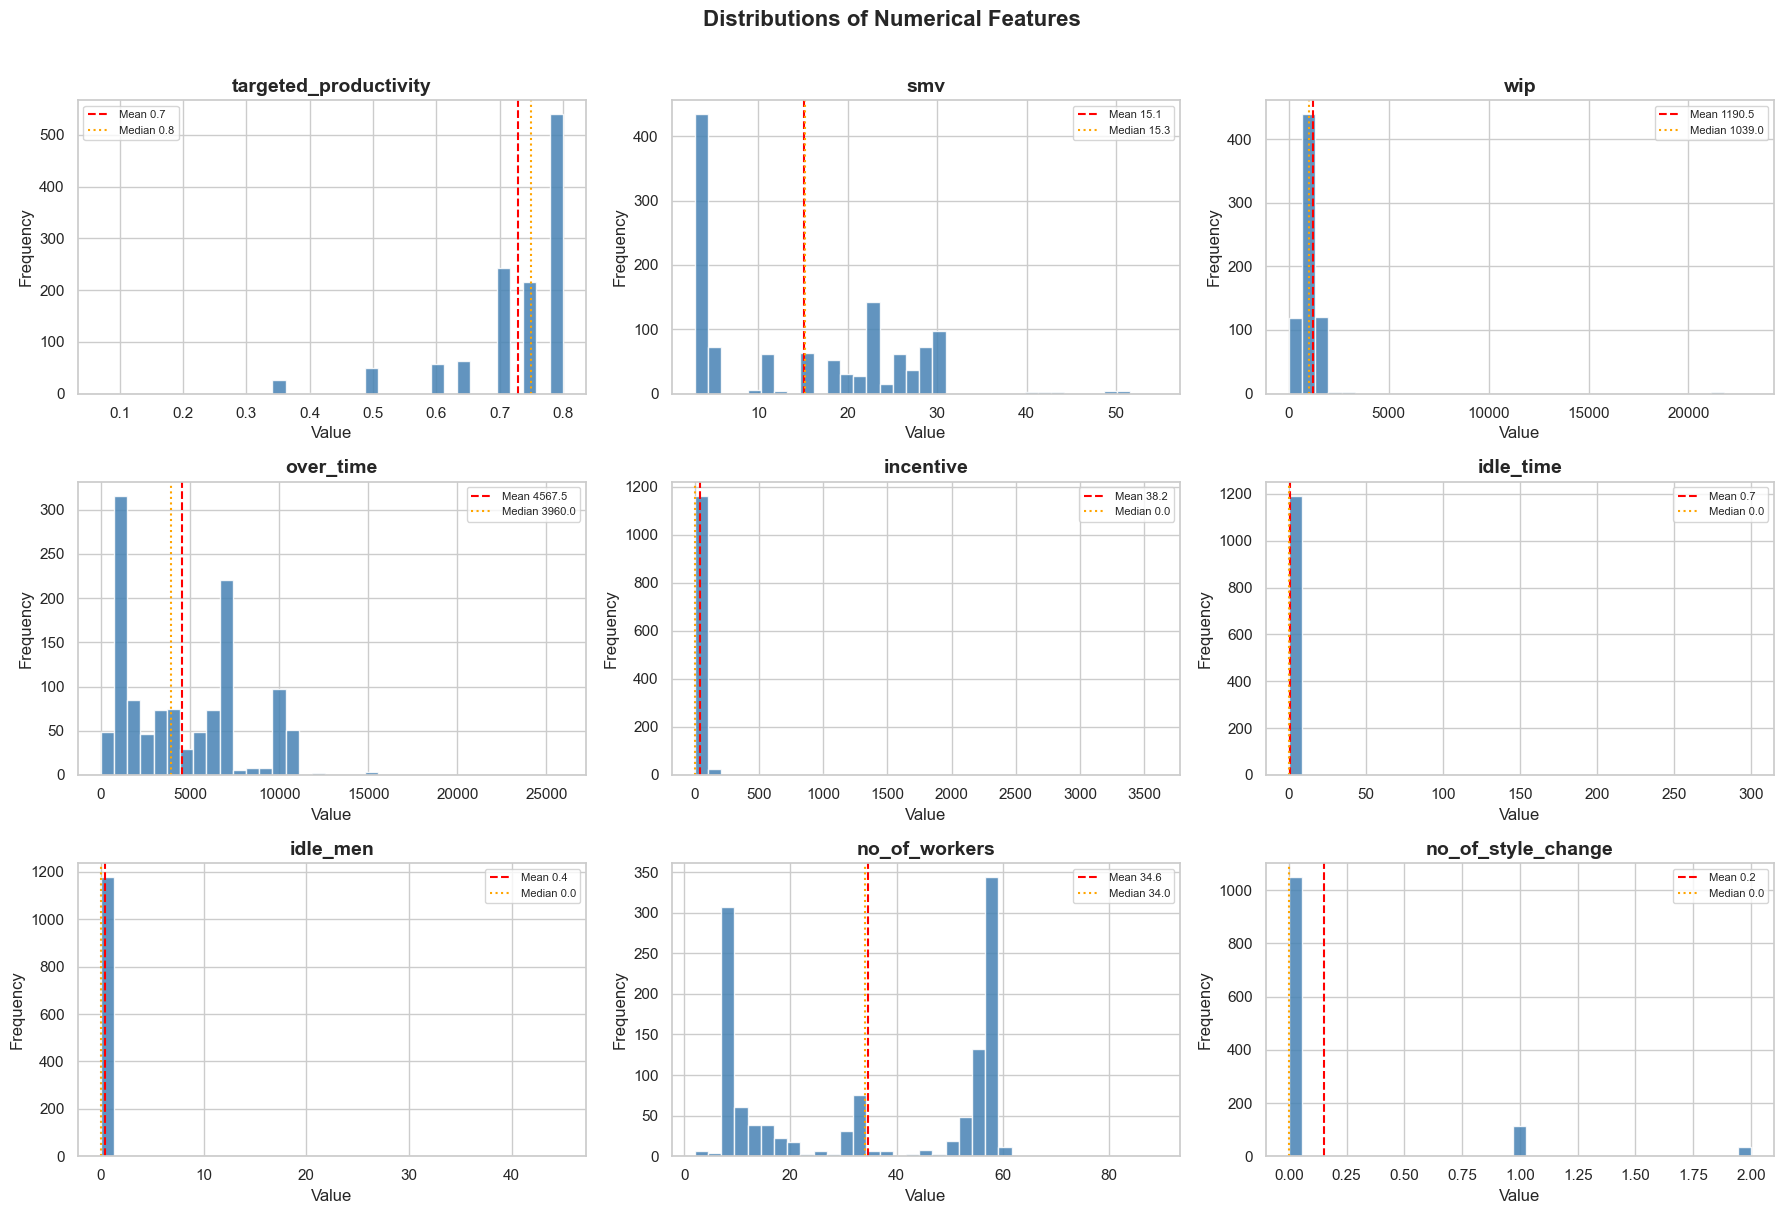

In [7]:
n_cols = 3
n_rows = -(-len(NUMERICAL_FEATURES) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_FEATURES):
    ax = axes[i]
    data = df[col].dropna()

    ax.hist(data, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

    mean_val   = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5,
               label=f'Mean {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.5,
               label=f'Median {median_val:.1f}')
    ax.legend(fontsize=8)

# Hide any leftover empty subplots
for j in range(len(NUMERICAL_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Numerical Features', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('../data/cleaned', exist_ok=True)
plt.savefig('../data/cleaned/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Saved → data/cleaned/eda_distributions.png')

---
## 1A.5 — Correlation Heatmap

**What to look for:**
- Which features have the **strongest correlation with `actual_productivity`** (bottom row / last column)
- Highly correlated feature pairs (|r| > 0.8) — may cause multicollinearity issues in linear models
- Green = positive correlation, Red = negative correlation

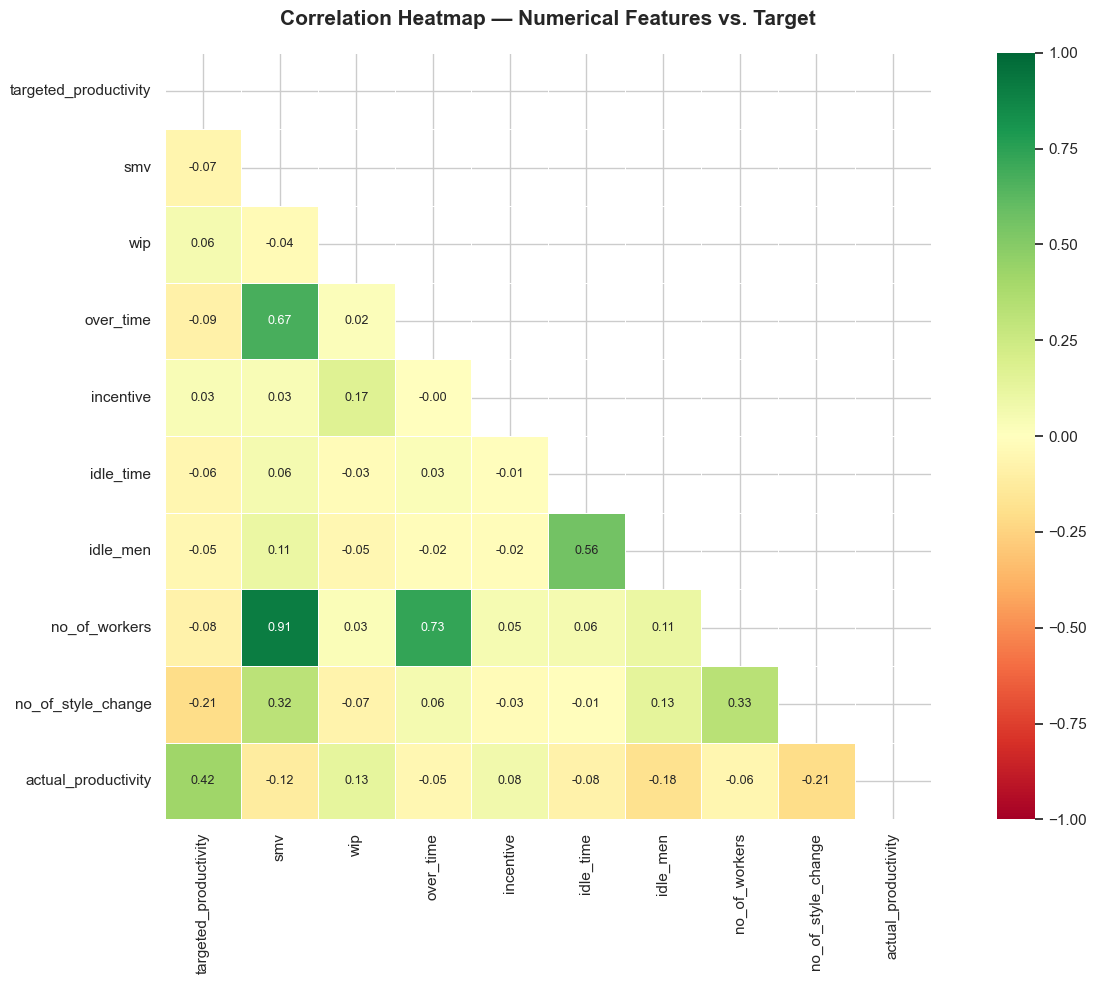

📁 Saved → data/cleaned/eda_heatmap.png

📈 Feature correlations with "actual_productivity" (ranked):
targeted_productivity    0.4216
wip                      0.1311
incentive                0.0765
over_time               -0.0542
no_of_workers           -0.0580
idle_time               -0.0809
smv                     -0.1221
idle_men                -0.1817
no_of_style_change      -0.2074


In [8]:
corr_cols   = NUMERICAL_FEATURES + [TARGET]
corr_matrix = df[corr_cols].corr()

# Mask the upper triangle to avoid duplication
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title(
    'Correlation Heatmap — Numerical Features vs. Target',
    fontsize=15, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('../data/cleaned/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Saved → data/cleaned/eda_heatmap.png')

# Print ranked correlations with the target
print(f'\n📈 Feature correlations with "{TARGET}" (ranked):')
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print(target_corr.round(4).to_string())

---
## 1A.6 — Target Variable Analysis

**What to look for:**
- **Skewness** — a left-skewed target means most workers exceed their quota
- **Outliers** — values above 1.0 exist in this dataset and need to be clipped
- **Hit rate** — what % of workers actually meet their `targeted_productivity`?

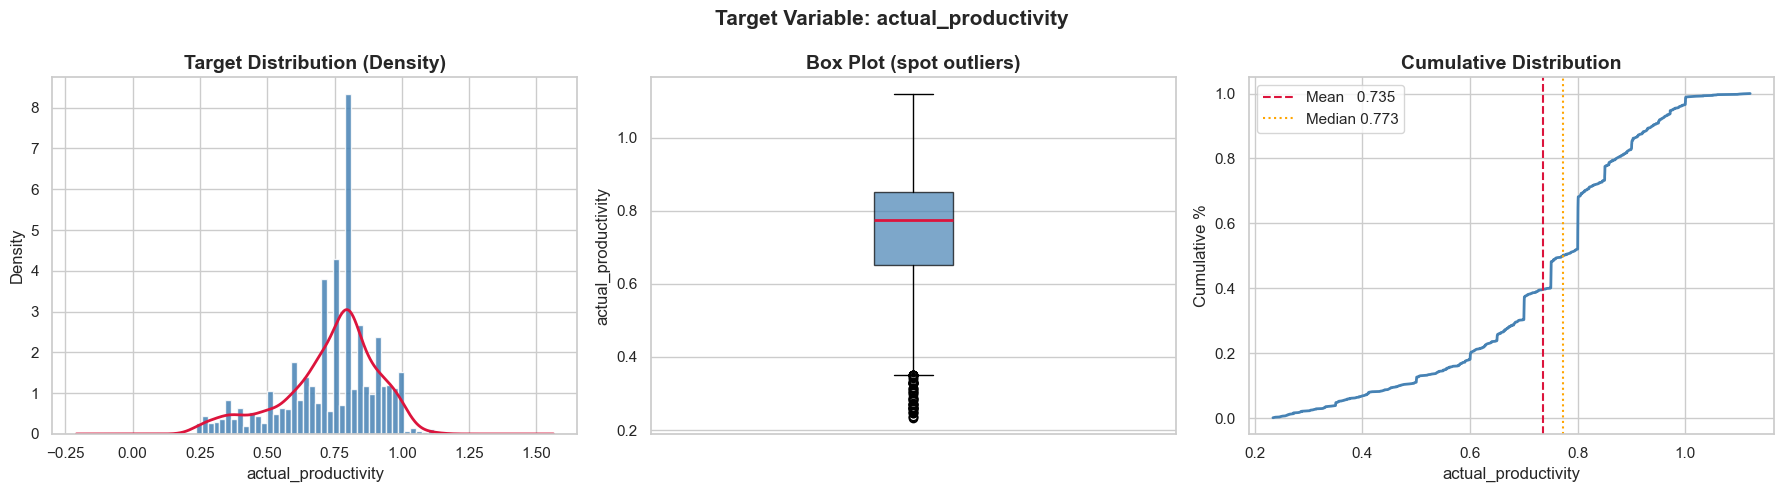

📁 Saved → data/cleaned/eda_target_analysis.png

TARGET VARIABLE STATISTICS
  Mean           : 0.7351
  Median         : 0.7733
  Std Dev        : 0.1745
  Min            : 0.2337
  Max            : 1.1204  (values > 1 exist — clip in 1B!)
  Skewness       : -0.8065  (Left-skewed ← most workers cluster near/above quota)
  Kurtosis       : 0.3268
  Shapiro-Wilk p : 0.0000  (Non-normal)

  ✅ Workers meeting/exceeding quota : 73.1%
  ⚠️  Workers falling below quota    : 26.9%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

target_data = df[TARGET].dropna()

# --- Plot 1: Histogram + KDE ---
axes[0].hist(target_data, bins=40, color='steelblue',
             edgecolor='white', alpha=0.85, density=True)
target_data.plot.kde(ax=axes[0], color='crimson', linewidth=2)
axes[0].set_title('Target Distribution (Density)', fontweight='bold')
axes[0].set_xlabel('actual_productivity')
axes[0].set_ylabel('Density')

# --- Plot 2: Box plot ---
axes[1].boxplot(target_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('Box Plot (spot outliers)', fontweight='bold')
axes[1].set_ylabel('actual_productivity')
axes[1].set_xticks([])

# --- Plot 3: Cumulative distribution ---
sorted_vals = np.sort(target_data)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[2].plot(sorted_vals, cdf, color='steelblue', linewidth=2)
axes[2].axvline(target_data.mean(),   color='crimson', linestyle='--',
                label=f'Mean   {target_data.mean():.3f}')
axes[2].axvline(target_data.median(), color='orange',  linestyle=':',
                label=f'Median {target_data.median():.3f}')
axes[2].set_title('Cumulative Distribution', fontweight='bold')
axes[2].set_xlabel('actual_productivity')
axes[2].set_ylabel('Cumulative %')
axes[2].legend()

plt.suptitle('Target Variable: actual_productivity', fontsize=15,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/cleaned/eda_target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Saved → data/cleaned/eda_target_analysis.png')

# --- Stats summary ---
skewness   = stats.skew(target_data)
kurt       = stats.kurtosis(target_data)
_, pval    = stats.shapiro(target_data.sample(min(5000, len(df)), random_state=42))

skew_label = (
    '(Left-skewed ← most workers cluster near/above quota)' if skewness < -0.5
    else '(Right-skewed → most workers fall below quota)'   if skewness >  0.5
    else '(Roughly symmetric)'
)

print()
print('=' * 58)
print('TARGET VARIABLE STATISTICS')
print('=' * 58)
print(f'  Mean           : {target_data.mean():.4f}')
print(f'  Median         : {target_data.median():.4f}')
print(f'  Std Dev        : {target_data.std():.4f}')
print(f'  Min            : {target_data.min():.4f}')
print(f'  Max            : {target_data.max():.4f}  (values > 1 exist — clip in 1B!)')
print(f'  Skewness       : {skewness:.4f}  {skew_label}')
print(f'  Kurtosis       : {kurt:.4f}')
print(f'  Shapiro-Wilk p : {pval:.4f}  {"(Non-normal)" if pval < 0.05 else "(Roughly normal)"}')
print()
hit_rate  = (df['actual_productivity'] >= df['targeted_productivity']).mean() * 100
miss_rate = 100 - hit_rate
print(f'  ✅ Workers meeting/exceeding quota : {hit_rate:.1f}%')
print(f'  ⚠️  Workers falling below quota    : {miss_rate:.1f}%')

---
## ✅ Phase 1A Complete — What to Carry into 1B (Cleaning)

After running all cells above, record your findings here before moving on:

| Observation | Action in 1B |
|-------------|-------------|
| `wip` has missing values | Impute with column median |
| `actual_productivity` has values > 1.0 | Clip to max 1.0 |
| Right-skewed features (overtime, incentive) | Note for feature engineering |
| Categorical columns as strings | One-hot encode in 1B |

> **Next notebook:** `02_model_training.ipynb` (after 1B and 1C are done in this notebook or a separate one)